# Module 0: Monte Carlo Simulation

Many probabilities and expected values can be computed exactly in simple examples. In more complicated stochastic models, exact calculations may be difficult or unavailable.

Monte Carlo simulation gives a simple computational alternative. We repeat a random experiment many times, record the outcomes, and use averages or relative frequencies as estimates.

This module introduces the basic simulation workflow used throughout the later modules. We first define a random experiment, then repeat it many times, compute an estimate, and compare the simulation result with a known theoretical value when available.

The examples are intentionally elementary. Their purpose is to introduce the method before it is applied to stochastic processes.

## Libraries

Run the cell below before you start the examples. The same basic figure format is used throughout the module, so the plots are easy to compare.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

plt.rcParams["lines.markersize"] = 4

## Example 1: Mean value of one die

We start with a simple Monte Carlo experiment.

The question is:

**What is the expected value if we throw a fair die many times?**

The exact value is easy to compute:

$$
\mu = \frac{1+2+3+4+5+6}{6}=3.5.
$$

We will use this simple example to illustrate the Monte Carlo idea.

The principle is to repeat the same random experiment many times and then compute the mean of the results.

A typical Monte Carlo procedure is:

```text
for i = 1, 2, ..., N:
    simulate one die throw
    store the result

compute the mean of all results
```

### Simulating one die throw

Simulate one throw of a fair die by generating one uniform random number $U$ in the interval $[0,1)$ and defining

$$
D = \lfloor 6U \rfloor + 1.
$$

The interval $[0,1)$ is divided into six subintervals of equal length, so each die value $1,2,\ldots,6$ has probability $1/6$. Run the cell several times and check that the output is always one of these six values.

In [3]:
# Start one random experiment
rng = np.random.default_rng()

# Generate one uniform random number
U = rng.random()

# Transform the random number into a die value
D = int(np.floor(6 * U) + 1)

print("U =", U)
print("D =", D)

U = 0.29695863609368567
D = 2


### Repeating the experiment

Repeat the die throw $N$ times and compute the simulated mean. If the simulated die values are $D_1,D_2,\ldots,D_N$, the Monte Carlo estimate of the expected value is

$$
\widehat{\mu}_N = \frac{1}{N}\sum_{i=1}^{N}D_i.
$$

For comparison, the theoretical mean is

$$
E[D] = \frac{1+2+3+4+5+6}{6} = 3.5.
$$

Run the code and compare the simulated mean with $3.5$.

In [24]:
# Choose the number of repetitions
N = 10000

# Start the Monte Carlo simulation
rng = np.random.default_rng()

# Store the result from each repetition
results = []

# Repeat the same random experiment
for i in range(N):
    U = rng.random()
    D = int(np.floor(6 * U) + 1)
    results.append(D)

# Estimate the expected value by the sample mean
dice_mean = np.mean(results)

print("N =", N)
print("Simulated mean =", dice_mean)
print("Theoretical mean = 3.5")

N = 10000
Simulated mean = 3.5006
Theoretical mean = 3.5


### Task 1

Change the value of $N$ and run the simulation again. Try

$$
N = 100,\quad 1000,\quad 10000.
$$

Write down the simulated mean for each value of $N$ and describe what happens when $N$ becomes larger.

In [5]:
# Repeat the experiment with a new value of N.
# Suggested values: 100, 1000, 10000, 100000.

### Example solution

The exact value is $3.5$. For large $N$, the simulated mean should usually be closer to this value.

In [6]:
# Compare several numbers of repetitions
N_values = [100, 1000, 10000, 100000]

# Use the same simulation rule for each value of N
rng = np.random.default_rng()

for N in N_values:
    results = []

    # Generate N independent die throws
    for i in range(N):
        U = rng.random()
        D = int(np.floor(6 * U) + 1)
        results.append(D)

    # Estimate the mean for this value of N
    dice_mean = np.mean(results)

    print("N =", N, "Simulated mean =", dice_mean)

N = 100 Simulated mean = 3.41
N = 1000 Simulated mean = 3.415
N = 10000 Simulated mean = 3.4932
N = 100000 Simulated mean = 3.49406


## Example 2: Probability with two dice

Now we use Monte Carlo simulation to estimate a probability.

The question is:

**What is the probability that the sum of two fair dice is at least 10?**

Let $D_1$ and $D_2$ be the two die outcomes. We want to estimate

$$
P(D_1 + D_2 \geq 10).
$$

For two fair dice, there are $36$ possible outcomes.

The event $D_1 + D_2 \geq 10$ occurs for the following outcomes:

$$
(4,6), (5,5), (5,6), (6,4), (6,5), (6,6).
$$

There are $6$ favourable outcomes, so the exact probability is

$$
P(D_1+D_2\geq 10)=\frac{6}{36}=\frac{1}{6}.
$$

In [28]:
# Choose the number of repeated experiments
N = 10000

# Store the exact probability for comparison
theoretical_probability = 1 / 6

# Start the Monte Carlo simulation
rng = np.random.default_rng()

# Count successful repetitions
count = 0

# Repeat the two dice experiment
for i in range(N):
    U1 = rng.random()
    U2 = rng.random()

    D1 = int(np.floor(6 * U1) + 1)
    D2 = int(np.floor(6 * U2) + 1)

    if D1 + D2 >= 10:
        count = count + 1

# Estimate the probability by relative frequency
p_hat = count / N

print("N =", N)
print("Simulated probability =", p_hat)
print("Theoretical probability =", theoretical_probability)

N = 10000
Simulated probability = 0.1678
Theoretical probability = 0.16666666666666666


### Task 2

Change the event in the simulation. For example, estimate one of the following probabilities:

$$
P(D_1 + D_2 = 7),
$$

$$
P(D_1 + D_2 \leq 4),
$$

or

$$
P(\max(D_1,D_2)=6).
$$

Run the simulation, compute the theoretical probability, and compare the two values.

In [8]:
# Change the event and repeat the probability estimate.
# For example, try D1 + D2 == 7, D1 + D2 <= 4, or max(D1, D2) == 6.

### Example solution

The example below estimates $P(D_1+D_2=7)$. Use the same structure for the other events.

In [29]:
# Estimate a different two dice event

N = 10000
rng = np.random.default_rng()

count = 0

for i in range(N):
    U1 = rng.random()
    U2 = rng.random()

    D1 = int(np.floor(6 * U1) + 1)
    D2 = int(np.floor(6 * U2) + 1)

    # Change this condition to choose the event
    # Examples: D1 + D2 == 7, D1 + D2 <= 4, max(D1, D2) == 6
    if D1 + D2 == 7:
        count = count + 1

p_hat = count / N

print("N =", N)
print("Simulated probability =", p_hat)

N = 10000
Simulated probability = 0.1642


## Example 3: Effect of increasing $N$

Study how the Monte Carlo estimate changes when more simulations are added. Use the same event as before:

$$
D_1 + D_2 \geq 10.
$$

The theoretical probability is

$$
P(D_1+D_2\geq 10)=\frac{1}{6}.
$$

In [33]:
# Compare several numbers of repetitions
N_values = [100, 1000, 10000, 100000]

# Store the exact probability for comparison
theoretical_probability = 1 / 6

# Start the Monte Carlo simulation
rng = np.random.default_rng()

# Store one estimate for each value of N
estimates = []

for N in N_values:
    count = 0

    # Generate N independent two dice experiments
    for i in range(N):
        U1 = rng.random()
        U2 = rng.random()

        D1 = int(np.floor(6 * U1) + 1)
        D2 = int(np.floor(6 * U2) + 1)

        if D1 + D2 >= 10:
            count = count + 1

    # Estimate the probability for this value of N
    p_hat = count / N
    estimates.append(p_hat)

    print("N =", N, "Simulated probability =", p_hat)

print("Theoretical probability =", theoretical_probability)

N = 100 Simulated probability = 0.18
N = 1000 Simulated probability = 0.173
N = 10000 Simulated probability = 0.1693
N = 100000 Simulated probability = 0.16825
Theoretical probability = 0.16666666666666666


### Convergence of the Monte Carlo estimate

To see how the estimate changes as more simulations are added, we compute a cumulative estimate.

After the first $n$ simulations, the estimate is

$$
\hat p_n = \frac{1}{n}\sum_{i=1}^{n}\mathbf{1}\{D_{1,i}+D_{2,i}\geq 10\}.
$$

Here $\mathbf{1}\{D_{1,i}+D_{2,i}\geq 10\}$ is equal to $1$ if the event occurs in simulation $i$, and $0$ otherwise. As $n$ increases, the estimate should fluctuate less and stay close to the theoretical probability.


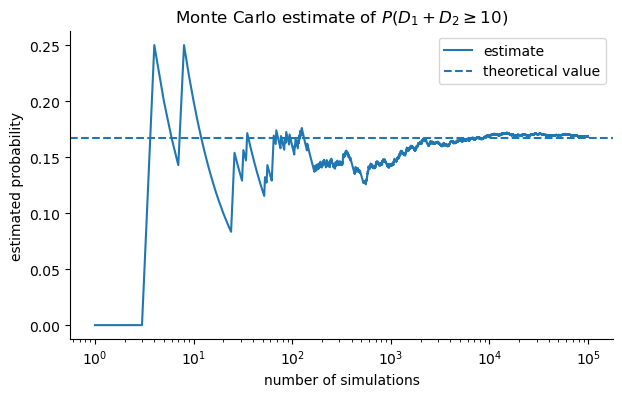

In [49]:
# Choose the largest number of repetitions
N_max = 100000

# Store the exact probability for comparison
p_exact = 1 / 6

# Start the Monte Carlo simulation
rng = np.random.default_rng()

# Generate all two dice experiments at once
U1 = rng.random(N_max)
U2 = rng.random(N_max)

D1 = np.floor(6 * U1).astype(int) + 1
D2 = np.floor(6 * U2).astype(int) + 1

# Record whether the event occurs in each experiment
events = (D1 + D2 >= 10)

# Compute the estimate after each additional repetition
p_hat = np.cumsum(events) / np.arange(1, N_max + 1)

# Compare the running estimate with the exact probability
n_values = np.arange(1, N_max + 1)

plt.figure(figsize=(7, 4))
plt.plot(n_values, p_hat, label="estimate")
plt.axhline(p_exact, linestyle="--", label="theoretical value")

plt.xscale("log")
plt.xlabel("number of simulations")
plt.ylabel("estimated probability")
plt.title("Monte Carlo estimate of $P(D_1 + D_2 \\geq 10)$")
plt.legend()
plt.show()